In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense

In [3]:
from google.colab import files
uploaded = files.upload()

import pandas as pd

df = pd.read_csv(list(uploaded.keys())[0])
df.head()

Saving airline-passengers.csv to airline-passengers.csv


,Month,Passengers
0,1949-01,112
1,1949-02,118
2,1949-03,132
3,1949-04,129
4,1949-05,121


In [4]:
data = df['Passengers'].values.reshape(-1,1)

scaler = MinMaxScaler()
data = scaler.fit_transform(data)

In [5]:
X = []
y = []

for i in range(10, len(data)):
    X.append(data[i-10:i])
    y.append(data[i])

X, y = np.array(X), np.array(y)

In [6]:
split = int(0.8 * len(X))

X_train, X_test = X[:split], X[split:]
y_train, y_test = y[:split], y[split:]

In [7]:
model = Sequential()

model.add(LSTM(50, activation='relu', input_shape=(X.shape[1], 1)))
model.add(Dense(1))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
model.compile(optimizer='adam', loss='mse')

In [9]:
history = model.fit(
    X_train, y_train,
    epochs=20,
    validation_data=(X_test, y_test)
)

Epoch 1/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 3s 166ms/step - loss: 0.0873 - val_loss: 0.2808
Epoch 2/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step - loss: 0.0652 - val_loss: 0.2122
Epoch 3/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0457 - val_loss: 0.1467
Epoch 4/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step - loss: 0.0286 - val_loss: 0.0868
Epoch 5/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0160 - val_loss: 0.0401
Epoch 6/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0120 - val_loss: 0.0243
Epoch 7/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0145 - val_loss: 0.0241
Epoch 8/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0130 - val_loss: 0.0257
Epoch 9/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0104 - val_loss: 0.0320
Epoch 10/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - loss: 0.0098 - val_loss: 0.0373
Epoch 11/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step - loss: 0.0103 - val_loss: 0.0378
Epoch 12/20
4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step - loss: 0.0101 - val_loss: 0.0333


In [10]:
pred = model.predict(X_test)

# Convert back to original scale
pred = scaler.inverse_transform(pred)
y_test_actual = scaler.inverse_transform(y_test)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 439ms/step


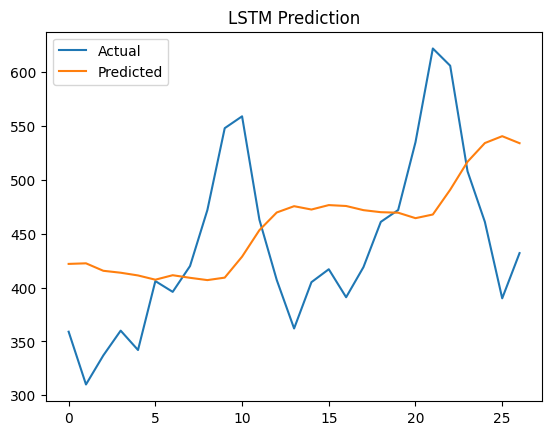

In [11]:
plt.plot(y_test_actual, label="Actual")
plt.plot(pred, label="Predicted")
plt.legend()
plt.title("LSTM Prediction")
plt.show()